In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import joblib
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv(
    r"C:\Users\vijay\OneDrive\Desktop\Vessel Performance\fuelcast_combined_raw.csv",
    
)

In [3]:
df.head()

,Consumer_Boiler_FuelType,Consumer_Boiler_MomentaryFuel,Consumer_GeneratorEngine1_FuelType,Consumer_GeneratorEngine1_MomentaryFuel,Consumer_GeneratorEngine1_ShaftPower,Consumer_GeneratorEngine2_FuelType,Consumer_GeneratorEngine2_MomentaryFuel,Consumer_GeneratorEngine2_ShaftPower,Consumer_MainEnginePort_FuelType,Consumer_MainEnginePort_MomentaryFuel,...,Consumer_EngineRoom1_FuelType,Consumer_EngineRoom1_MomentaryFuel,Consumer_EngineRoom1_RotationSpeed,Consumer_EngineRoom1_ShaftPower,Consumer_EngineRoom2_FuelType,Consumer_EngineRoom2_MomentaryFuel,Consumer_EngineRoom2_RotationSpeed,Consumer_EngineRoom2_ShaftPower,Consumer_Incinerator_FuelType,Consumer_Incinerator_MomentaryFuel
0,HVO 30,0.0,HVO 30,0.0,0.0,HVO 30,0.0,0.0,HVO 30,0.103229,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HVO 30,0.0,HVO 30,0.0,0.0,HVO 30,0.0,0.0,HVO 30,0.103622,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HVO 30,0.0,HVO 30,0.0,0.0,HVO 30,0.0,0.0,HVO 30,0.102990,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HVO 30,0.0,HVO 30,0.0,0.0,HVO 30,0.0,0.0,HVO 30,0.102945,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HVO 30,0.0,HVO 30,0.0,0.0,HVO 30,0.0,0.0,HVO 30,0.103787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173982 entries, 0 to 173981
Data columns (total 93 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Consumer_Boiler_FuelType                    25347 non-null   object 
 1   Consumer_Boiler_MomentaryFuel               25337 non-null   float64
 2   Consumer_GeneratorEngine1_FuelType          130769 non-null  object 
 3   Consumer_GeneratorEngine1_MomentaryFuel     130732 non-null  float64
 4   Consumer_GeneratorEngine1_ShaftPower        128485 non-null  float64
 5   Consumer_GeneratorEngine2_FuelType          130769 non-null  object 
 6   Consumer_GeneratorEngine2_MomentaryFuel     130732 non-null  float64
 7   Consumer_GeneratorEngine2_ShaftPower        128485 non-null  float64
 8   Consumer_MainEnginePort_FuelType            25347 non-null   object 
 9   Consumer_MainEnginePort_MomentaryFuel       25337 non-null   float64
 

In [5]:
df['vessel_name'].value_counts()

CPS_Poseidon    105422
OSS_Ceto         43213
CPS_Triton       25347
Name: vessel_name, dtype: int64

In [6]:
df.describe()

,Consumer_Boiler_MomentaryFuel,Consumer_GeneratorEngine1_MomentaryFuel,Consumer_GeneratorEngine1_ShaftPower,Consumer_GeneratorEngine2_MomentaryFuel,Consumer_GeneratorEngine2_ShaftPower,Consumer_MainEnginePort_MomentaryFuel,Consumer_MainEnginePort_RotationSpeed,Consumer_MainEnginePort_ShaftPower,Consumer_MainEngineStarboard_MomentaryFuel,Consumer_MainEngineStarboard_RotationSpeed,...,Consumer_GeneratorEngine5_RotationSpeed,Consumer_GeneratorEngine5_ShaftPower,Consumer_DeckSupply_MomentaryFuel,Consumer_EngineRoom1_MomentaryFuel,Consumer_EngineRoom1_RotationSpeed,Consumer_EngineRoom1_ShaftPower,Consumer_EngineRoom2_MomentaryFuel,Consumer_EngineRoom2_RotationSpeed,Consumer_EngineRoom2_ShaftPower,Consumer_Incinerator_MomentaryFuel
count,25337.000000,130732.000000,1.284850e+05,130732.000000,1.284850e+05,25337.000000,25337.000000,2.533700e+04,25337.000000,25337.000000,...,103148.000000,1.031480e+05,43161.000000,43178.000000,40239.000000,4.320400e+04,43182.000000,39789.000000,4.320400e+04,43181.000000
mean,0.004487,0.134374,2.334293e+06,0.133411,2.241700e+06,0.089492,403.499643,1.091712e+06,0.075580,403.499643,...,164.973823,2.097843e+06,0.000262,0.095306,719.684835,1.411400e+06,0.092199,719.862632,1.196457e+06,0.000035
std,0.008886,0.190773,3.337588e+06,0.193374,3.347185e+06,0.042897,172.847228,6.118868e+05,0.037490,172.847228,...,238.142105,3.228819e+06,0.002407,0.058332,7.460399,1.023533e+06,0.058824,6.608876,1.027987e+06,0.000670
min,0.000000,0.000000,0.000000e+00,-0.004328,-6.792500e+04,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,110.000000,-1.200000e+03,0.000000,242.000000,0.000000e+00,0.000000
25%,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.073061,482.980000,6.113400e+05,0.060785,482.980000,...,0.000000,0.000000e+00,0.000000,0.060964,719.400000,9.600000e+05,0.067472,719.600000,7.550000e+05,0.000000
50%,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.108251,487.040000,1.346020e+06,0.088734,487.040000,...,0.000000,0.000000e+00,0.000000,0.097595,720.200000,1.242000e+06,0.084333,720.400000,9.496000e+05,0.000000
75%,0.005606,0.336776,5.804600e+06,0.347359,5.829400e+06,0.116909,488.880000,1.511100e+06,0.100495,488.880000,...,511.000000,5.330200e+06,0.000000,0.113740,720.800000,1.533800e+06,0.102491,720.900000,1.228000e+06,0.000000
max,0.078126,0.567226,9.268800e+06,0.539853,9.346200e+06,0.179608,496.180000,2.745080e+06,0.172005,496.180000,...,517.000000,9.198400e+06,0.172200,0.422851,734.100000,7.294800e+06,0.528766,726.400000,8.950400e+06,0.049519


In [7]:
df = df.dropna(
    subset=[
        "Consumer_MainEnginePort_MomentaryFuel",
        "Consumer_MainEngineStarboard_MomentaryFuel"
    ],
    how="all"
)

df = df[
    (df["Consumer_MainEnginePort_MomentaryFuel"] > 0) &
    (df["Consumer_MainEngineStarboard_MomentaryFuel"] > 0)
]

In [8]:
df["ME_Total_MomentaryFuel"] = (
    df["Consumer_MainEnginePort_MomentaryFuel"].fillna(0) +
    df["Consumer_MainEngineStarboard_MomentaryFuel"].fillna(0)
)

In [9]:
df.drop(columns=[

    "Consumer_Boiler_FuelType",
    "Consumer_Boiler_MomentaryFuel",

    "Consumer_GeneratorEngine1_FuelType",
    "Consumer_GeneratorEngine1_MomentaryFuel",
    "Consumer_GeneratorEngine1_ShaftPower",
    "Consumer_GeneratorEngine1_RotationSpeed",

    "Consumer_GeneratorEngine2_FuelType",
    "Consumer_GeneratorEngine2_MomentaryFuel",
    "Consumer_GeneratorEngine2_ShaftPower",
    "Consumer_GeneratorEngine2_RotationSpeed",

    "Consumer_GeneratorEngine3_FuelType",
    "Consumer_GeneratorEngine3_MomentaryFuel",
    "Consumer_GeneratorEngine3_ShaftPower",
    "Consumer_GeneratorEngine3_RotationSpeed",

    "Consumer_GeneratorEngine4_FuelType",
    "Consumer_GeneratorEngine4_MomentaryFuel",
    "Consumer_GeneratorEngine4_ShaftPower",
    "Consumer_GeneratorEngine4_RotationSpeed",

    "Consumer_GeneratorEngine5_FuelType",
    "Consumer_GeneratorEngine5_MomentaryFuel",
    "Consumer_GeneratorEngine5_ShaftPower",
    "Consumer_GeneratorEngine5_RotationSpeed",

    "Consumer_MainEnginePort_MomentaryFuel",
    "Consumer_MainEngineStarboard_MomentaryFuel",

    "Consumer_Total_MomentaryFuel",
    "Consumer_Total_ShaftPower",

    "Consumer_Boiler1_FuelType",
    "Consumer_Boiler1_MomentaryFuel",

    "Consumer_Boiler2_FuelType",
    "Consumer_Boiler2_MomentaryFuel",

    "Consumer_DeckSupply_FuelType",
    "Consumer_DeckSupply_MomentaryFuel",

    "Consumer_EngineRoom1_FuelType",
    "Consumer_EngineRoom1_MomentaryFuel",
    "Consumer_EngineRoom1_RotationSpeed",
    "Consumer_EngineRoom1_ShaftPower",

    "Consumer_EngineRoom2_FuelType",
    "Consumer_EngineRoom2_MomentaryFuel",
    "Consumer_EngineRoom2_RotationSpeed",
    "Consumer_EngineRoom2_ShaftPower",

    "Consumer_Incinerator_FuelType",
    "Consumer_Incinerator_MomentaryFuel","index",'Consumer_MainEnginePort_FuelType',
       'Consumer_MainEngineStarboard_FuelType'
],inplace=True)

In [10]:
df.head()

,Consumer_MainEnginePort_RotationSpeed,Consumer_MainEnginePort_ShaftPower,Consumer_MainEngineStarboard_RotationSpeed,Consumer_MainEngineStarboard_ShaftPower,Environment_SeaFloorDepth,Propeller_Port_RotationSpeed,Propeller_Port_ShaftPower,Propeller_Port_ShaftTorque,Propeller_Starboard_RotationSpeed,Propeller_Starboard_ShaftPower,...,Weather_WeatherCode,Weather_WindDirection10M,Weather_WindGusts10M,Weather_WindSpeed10M,Weather_WindWaveDirection,Weather_WindWaveHeight,Weather_WindWavePeakPeriod,Weather_WindWavePeriod,vessel_name,ME_Total_MomentaryFuel
0,486.54,1273260.0,486.54,1276560.0,134.015552,165.40,1273260.0,73.48,162.68,1276560.0,...,2.0,333.000000,11.800000,8.1,329.000000,1.160000,NaN,4.0000,CPS_Triton,0.190798
1,486.44,1270060.0,486.44,1246520.0,121.069884,165.40,1270060.0,73.34,158.74,1246520.0,...,2.0,332.333333,11.558333,7.9,329.333333,1.126667,NaN,3.9375,CPS_Triton,0.191424
2,486.16,1260500.0,486.16,1267580.0,103.577109,165.36,1260500.0,72.80,161.78,1267580.0,...,2.0,331.666667,11.316667,7.7,329.666667,1.093333,NaN,3.8750,CPS_Triton,0.190519
3,486.26,1268440.0,486.26,1240720.0,88.533691,165.38,1268440.0,73.24,156.56,1240720.0,...,2.0,331.000000,11.075000,7.5,330.000000,1.060000,NaN,3.8125,CPS_Triton,0.190144
4,486.30,1270740.0,486.30,1282600.0,85.012128,165.36,1270740.0,73.36,163.22,1282600.0,...,2.0,330.333333,10.833333,7.3,330.333333,1.026667,NaN,3.7500,CPS_Triton,0.190660


In [11]:
df['Ship_SpeedThroughWater'].isnull().sum()

0

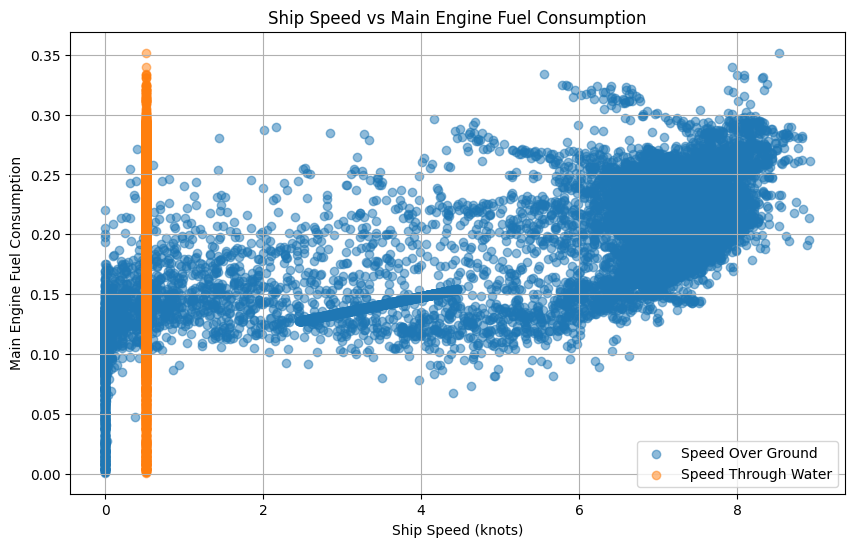

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Ship_SpeedOverGround"],
    df["ME_Total_MomentaryFuel"],
    alpha=0.5,
    label="Speed Over Ground"
)

plt.scatter(
    df["Ship_SpeedThroughWater"],
    df["ME_Total_MomentaryFuel"],
    alpha=0.5,
    label="Speed Through Water"
)

plt.xlabel("Ship Speed (knots)")
plt.ylabel("Main Engine Fuel Consumption")
plt.title("Ship Speed vs Main Engine Fuel Consumption")
plt.legend()
plt.grid(True)

plt.show()


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21564 entries, 0 to 25345
Data columns (total 49 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Consumer_MainEnginePort_RotationSpeed       21564 non-null  float64
 1   Consumer_MainEnginePort_ShaftPower          21564 non-null  float64
 2   Consumer_MainEngineStarboard_RotationSpeed  21564 non-null  float64
 3   Consumer_MainEngineStarboard_ShaftPower     21564 non-null  float64
 4   Environment_SeaFloorDepth                   21564 non-null  float64
 5   Propeller_Port_RotationSpeed                21564 non-null  float64
 6   Propeller_Port_ShaftPower                   21564 non-null  float64
 7   Propeller_Port_ShaftTorque                  21564 non-null  float64
 8   Propeller_Starboard_RotationSpeed           21564 non-null  float64
 9   Propeller_Starboard_ShaftPower              21564 non-null  float64
 10  Propeller_

In [14]:
df.head()

,Consumer_MainEnginePort_RotationSpeed,Consumer_MainEnginePort_ShaftPower,Consumer_MainEngineStarboard_RotationSpeed,Consumer_MainEngineStarboard_ShaftPower,Environment_SeaFloorDepth,Propeller_Port_RotationSpeed,Propeller_Port_ShaftPower,Propeller_Port_ShaftTorque,Propeller_Starboard_RotationSpeed,Propeller_Starboard_ShaftPower,...,Weather_WeatherCode,Weather_WindDirection10M,Weather_WindGusts10M,Weather_WindSpeed10M,Weather_WindWaveDirection,Weather_WindWaveHeight,Weather_WindWavePeakPeriod,Weather_WindWavePeriod,vessel_name,ME_Total_MomentaryFuel
0,486.54,1273260.0,486.54,1276560.0,134.015552,165.40,1273260.0,73.48,162.68,1276560.0,...,2.0,333.000000,11.800000,8.1,329.000000,1.160000,NaN,4.0000,CPS_Triton,0.190798
1,486.44,1270060.0,486.44,1246520.0,121.069884,165.40,1270060.0,73.34,158.74,1246520.0,...,2.0,332.333333,11.558333,7.9,329.333333,1.126667,NaN,3.9375,CPS_Triton,0.191424
2,486.16,1260500.0,486.16,1267580.0,103.577109,165.36,1260500.0,72.80,161.78,1267580.0,...,2.0,331.666667,11.316667,7.7,329.666667,1.093333,NaN,3.8750,CPS_Triton,0.190519
3,486.26,1268440.0,486.26,1240720.0,88.533691,165.38,1268440.0,73.24,156.56,1240720.0,...,2.0,331.000000,11.075000,7.5,330.000000,1.060000,NaN,3.8125,CPS_Triton,0.190144
4,486.30,1270740.0,486.30,1282600.0,85.012128,165.36,1270740.0,73.36,163.22,1282600.0,...,2.0,330.333333,10.833333,7.3,330.333333,1.026667,NaN,3.7500,CPS_Triton,0.190660


In [15]:
df.describe(include="all")

,Consumer_MainEnginePort_RotationSpeed,Consumer_MainEnginePort_ShaftPower,Consumer_MainEngineStarboard_RotationSpeed,Consumer_MainEngineStarboard_ShaftPower,Environment_SeaFloorDepth,Propeller_Port_RotationSpeed,Propeller_Port_ShaftPower,Propeller_Port_ShaftTorque,Propeller_Starboard_RotationSpeed,Propeller_Starboard_ShaftPower,...,Weather_WeatherCode,Weather_WindDirection10M,Weather_WindGusts10M,Weather_WindSpeed10M,Weather_WindWaveDirection,Weather_WindWaveHeight,Weather_WindWavePeakPeriod,Weather_WindWavePeriod,vessel_name,ME_Total_MomentaryFuel
count,21564.000000,2.156400e+04,21564.000000,2.156400e+04,21564.000000,21564.000000,2.156400e+04,21564.000000,21564.000000,2.156400e+04,...,21531.000000,21531.000000,21531.000000,21531.000000,21531.000000,21531.000000,17785.000000,21531.000000,21564,21564.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CPS_Triton,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21564,NaN
mean,471.179459,1.281444e+06,471.179459,1.268489e+06,80.171356,157.983965,1.281444e+06,74.403362,156.145598,1.268489e+06,...,21.499604,183.396784,10.114328,6.722181,188.722988,0.452854,2.437391,2.224180,NaN,0.193412
std,58.700730,4.432975e+05,58.700730,4.370263e+05,71.426093,27.246759,4.432975e+05,25.070105,22.258228,4.370263e+05,...,24.698150,93.286330,5.870260,4.094683,89.578554,0.510435,1.840810,1.427108,NaN,0.045299
min,0.000000,0.000000e+00,0.000000,0.000000e+00,-24.179025,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,1.000000,0.250000,0.000000,0.000000,1.000000,0.000000,NaN,0.000873
25%,484.700000,1.084745e+06,484.700000,1.070080e+06,17.978467,164.640000,1.084745e+06,63.195000,159.920000,1.070080e+06,...,2.333333,107.679789,5.670833,3.516667,130.750000,0.065000,1.000000,1.304167,NaN,0.172276
50%,487.800000,1.399850e+06,487.800000,1.382800e+06,60.320518,165.760000,1.399850e+06,80.660000,162.300000,1.382800e+06,...,3.000000,189.166667,8.958333,5.941667,190.333333,0.296667,2.000000,2.183333,NaN,0.203959
75%,489.160000,1.542600e+06,489.160000,1.526125e+06,134.780141,166.200000,1.542600e+06,88.685000,163.980000,1.526125e+06,...,51.000000,248.666667,13.300000,9.133333,253.791667,0.656667,3.000000,3.061310,NaN,0.220756


In [16]:
df.isnull().sum()

Consumer_MainEnginePort_RotationSpeed            0
Consumer_MainEnginePort_ShaftPower               0
Consumer_MainEngineStarboard_RotationSpeed       0
Consumer_MainEngineStarboard_ShaftPower          0
Environment_SeaFloorDepth                        0
Propeller_Port_RotationSpeed                     0
Propeller_Port_ShaftPower                        0
Propeller_Port_ShaftTorque                       0
Propeller_Starboard_RotationSpeed                0
Propeller_Starboard_ShaftPower                   0
Propeller_Starboard_ShaftTorque                  0
Propeller_Total_ShaftPower                       0
Ship_AirTemperature                              0
Ship_AnemometerWindDirection                     0
Ship_AnemometerWindSpeed                         0
Ship_Bearing                                     9
Ship_DraftAft                                    0
Ship_DraftFore                                   0
Ship_Heading                                     0
Ship_SpeedOverGround           

In [17]:
df=df.dropna()

In [18]:
df = df.drop_duplicates()

In [19]:
Q1 = df["ME_Total_MomentaryFuel"].quantile(0.25)
Q3 = df["ME_Total_MomentaryFuel"].quantile(0.75)
IQR = Q3 - Q1

df["ME_Total_MomentaryFuel"] = np.clip(
    df["ME_Total_MomentaryFuel"],
    Q1 - 1.5*IQR,
    Q3 + 1.5*IQR
)

In [20]:
df["Fuel_roll_mean_5"] = df["ME_Total_MomentaryFuel"].rolling(5).mean()
df["Fuel_roll_std_5"]  = df["ME_Total_MomentaryFuel"].rolling(5).std()

df.dropna(inplace=True)

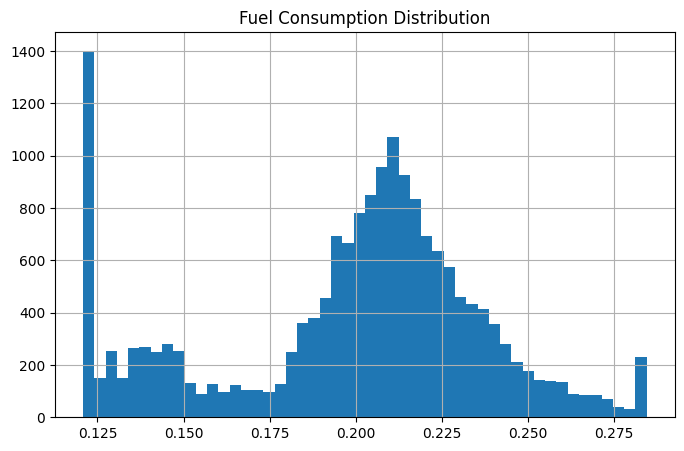

In [21]:
df["ME_Total_MomentaryFuel"].hist(bins=50, figsize=(8,5))
plt.title("Fuel Consumption Distribution")
plt.show()

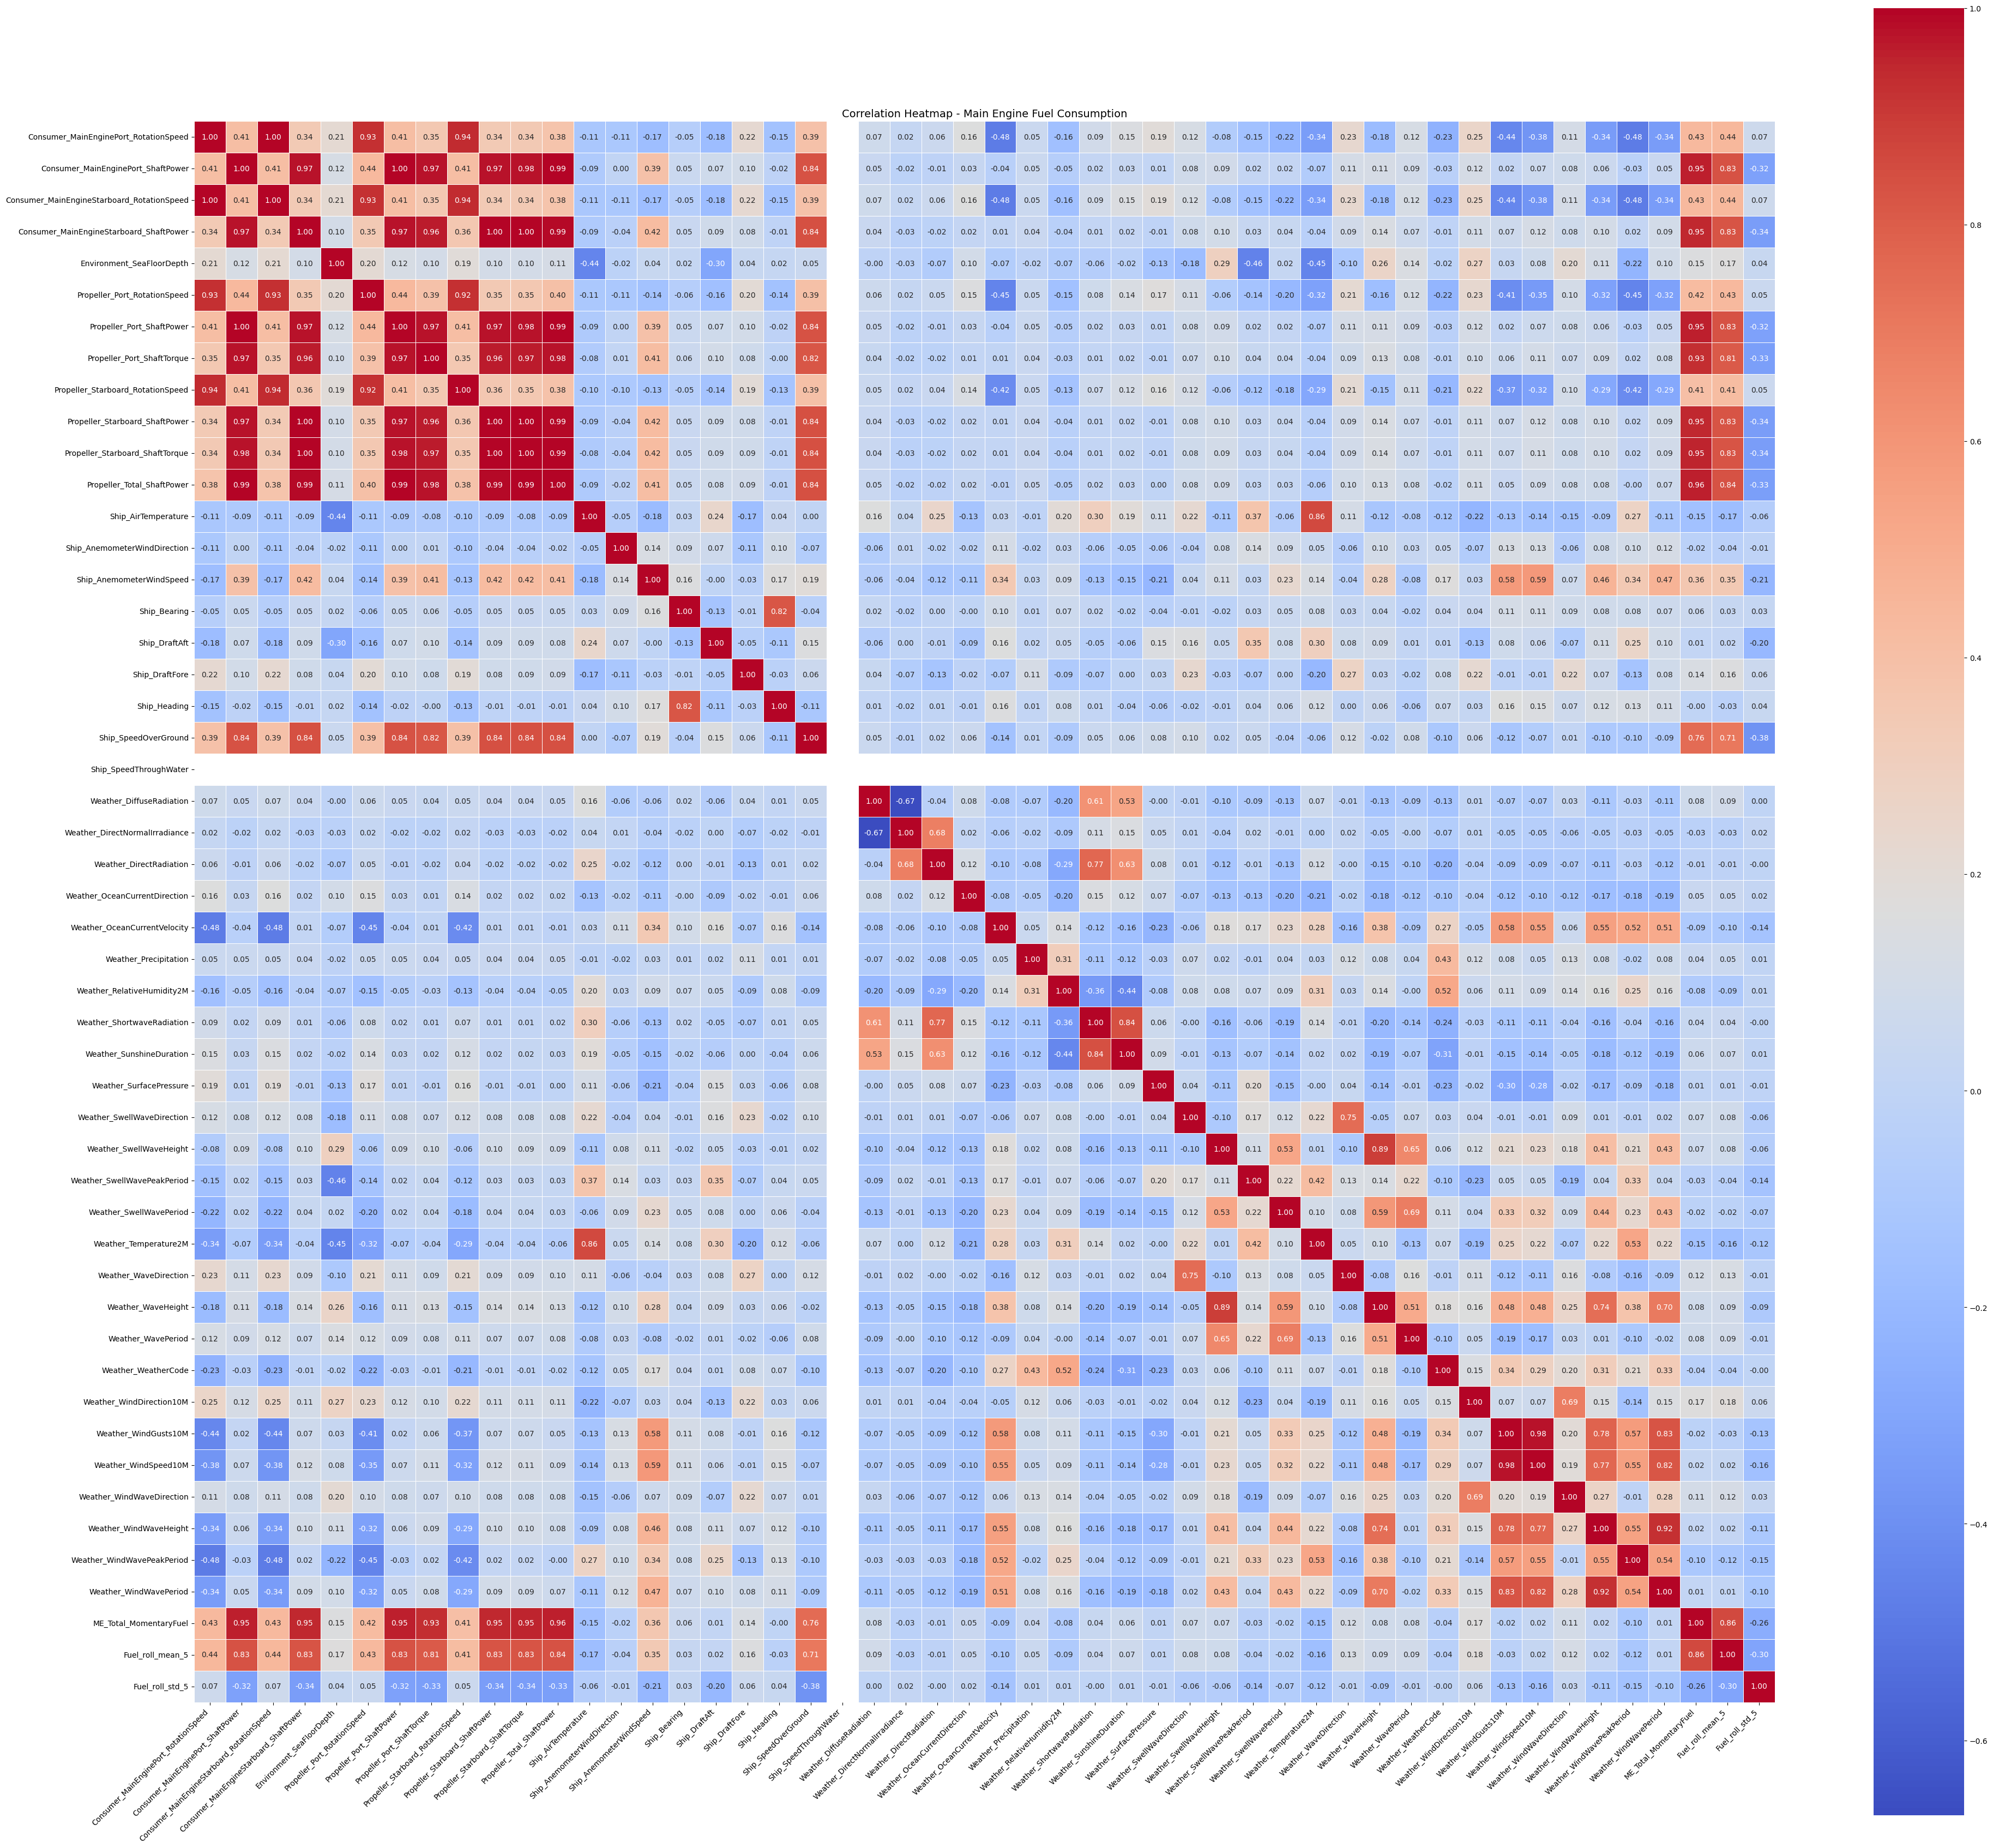

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(40, 35)) 
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Heatmap - Main Engine Fuel Consumption", fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
X = df.drop(columns=["ME_Total_MomentaryFuel"])
y = df["ME_Total_MomentaryFuel"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [24]:
import category_encoders as ce
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("encoder", ce.TargetEncoder(cols=["vessel_name"])),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)


print("RF MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF R2  :", r2_score(y_test, y_pred_rf))


RF MAE : 0.004162029459866886
RF RMSE: 0.006256506565827262
RF R2  : 0.9664739999508073


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

cat_cols = ["vessel_name"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("XGB MAE :", mean_absolute_error(y_test, y_pred))
print("XGB RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("XGB R2  :", r2_score(y_test, y_pred))


XGB MAE : 0.0050767792281746675
XGB RMSE: 0.006716314071380358
XGB R2  : 0.9613650881918152


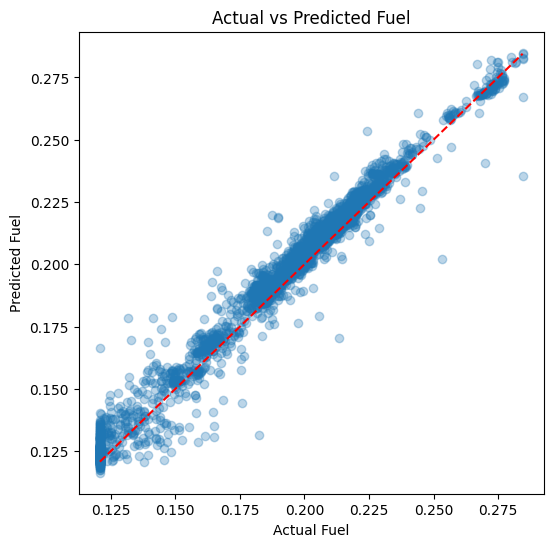

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Actual Fuel")
plt.ylabel("Predicted Fuel")
plt.title("Actual vs Predicted Fuel")
plt.show()

In [30]:
ohe = pipeline.named_steps["preprocess"].named_transformers_["cat"]
ohe_features = ohe.get_feature_names_out(["vessel_name"])

final_features = np.concatenate([
    ohe_features,
    num_cols
])

importance = pd.DataFrame({
    "feature": final_features,
    "importance": pipeline.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
8,Propeller_Port_ShaftTorque,0.744750
12,Propeller_Total_ShaftPower,0.146213
4,Consumer_MainEngineStarboard_ShaftPower,0.038044
11,Propeller_Starboard_ShaftTorque,0.021164
2,Consumer_MainEnginePort_ShaftPower,0.016003
30,Weather_SunshineDuration,0.006048
43,Weather_WindSpeed10M,0.002360
6,Propeller_Port_RotationSpeed,0.002253
48,Fuel_roll_mean_5,0.002196
20,Ship_SpeedOverGround,0.002110


In [31]:
joblib.dump(pipeline, "me_fuel_xgb_pipeline.pkl")

pipeline.named_steps["model"].get_booster().save_model(
    "me_fuel_xgb_booster.json"
)

print("✅ Model saved successfully")


✅ Model saved successfully


In [32]:
loaded_model = joblib.load("me_fuel_xgb_pipeline.pkl")

sample = X_test.iloc[:1]
prediction = loaded_model.predict(sample)

print("Predicted Fuel:", prediction)

Predicted Fuel: [0.25938758]
